### Step 1: Load the Libraies and Data

In [201]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.layers import LSTM, Dense, Dropout, GRU, Conv1D, Bidirectional
from keras.callbacks import EarlyStopping 

In [202]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_1468\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [203]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [204]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [205]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [206]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [207]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


In [208]:
x = [12]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # selecting the data for the month x
data1 = data1.reset_index(drop=True)  # resetting the index
data1 = data1.dropna()  # dropping the missing values

datas = data1['LV ActivePower (kW)']  # selecting the active power
datas_wind = pd.DataFrame(datas)  # converting to dataframe
dfs = datas  # copying the data
s = dfs.values 


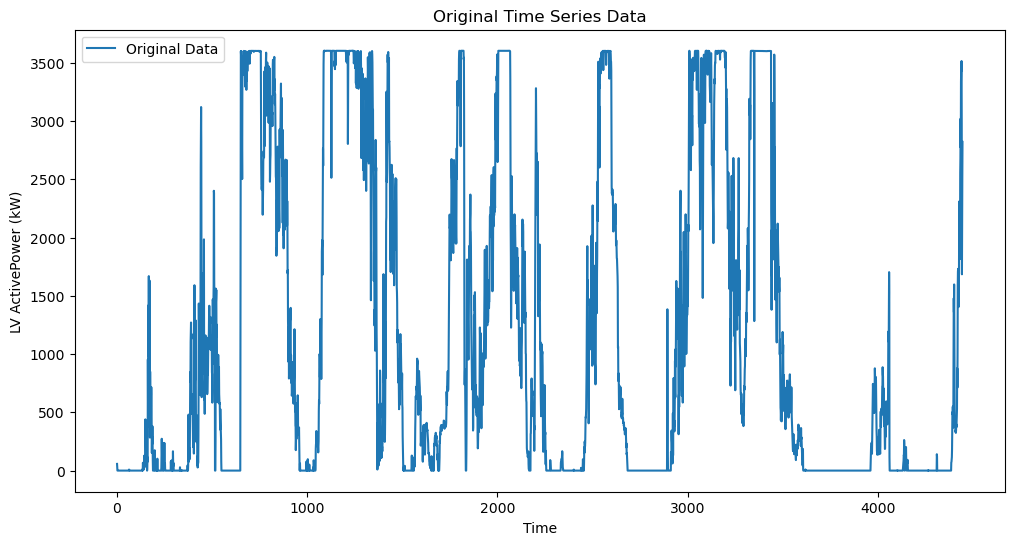

In [209]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(dfs.index, dfs.values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

In [210]:
# find the total number of rows
total_rows = datas_wind.count()
total_rows

LV ActivePower (kW)    4447
dtype: int64

In [211]:
s.shape

(4447,)

In [212]:
data1.shape

(4447, 10)

In [213]:
data1.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-12-01 00:00:00,57.407021,6.166973,681.780444,47.659679,2018,12,1,0,0
1,2018-12-01 00:10:00,27.440510,5.884330,586.656800,49.751839,2018,12,1,0,10
2,2018-12-01 00:20:00,0.364866,5.168109,378.397651,54.350288,2018,12,1,0,20
3,2018-12-01 00:30:00,0.000000,4.607421,245.089872,53.266201,2018,12,1,0,30
4,2018-12-01 00:40:00,0.000000,4.713554,268.621965,51.365490,2018,12,1,0,40


In [214]:
from PyEMD import EMD,EEMD,CEEMDAN
import ewtpy
# Perform CEEMDAN decomposition
emd = CEEMDAN(epsilon=0.05)
emd.noise_seed(12345)
IMFs = emd(s)

full_imf = pd.DataFrame(IMFs).T
ceemdan1 = full_imf

# Extract the first IMF
imf1 = ceemdan1.iloc[:, 0]
imf_dataps = np.array(imf1)
imf_datasetss = imf_dataps.reshape(-1, 1)
imf_new_datasets = pd.DataFrame(imf_datasetss)

# Perform EWT decomposition on the first IMF
ewt_coeffs, mfb, boundaries = ewtpy.EWT1D(imf1, N=3)
df_ewt = pd.DataFrame(ewt_coeffs)

# Remove the third column if it exists
if df_ewt.shape[1] > 2:
    df_ewt.drop(df_ewt.columns[2], axis=1, inplace=True)

# Sum the EWT components to get the denoised signal
denoised = df_ewt.sum(axis=1, skipna=True)

# Prepare the new CEEMDAN components by replacing the first IMF with the denoised signal
ceemdan_without_imf1 = ceemdan1.iloc[:, 1:].reset_index(drop=True)
denoised = denoised.reset_index(drop=True)
new_ceemdan = pd.concat([denoised, ceemdan_without_imf1], axis=1)
new_ceemdan.columns = range(new_ceemdan.shape[1])  # Reset column names

In [215]:
# Check the shape of the new CEEMDAN components
new_ceemdan.shape

(4447, 10)

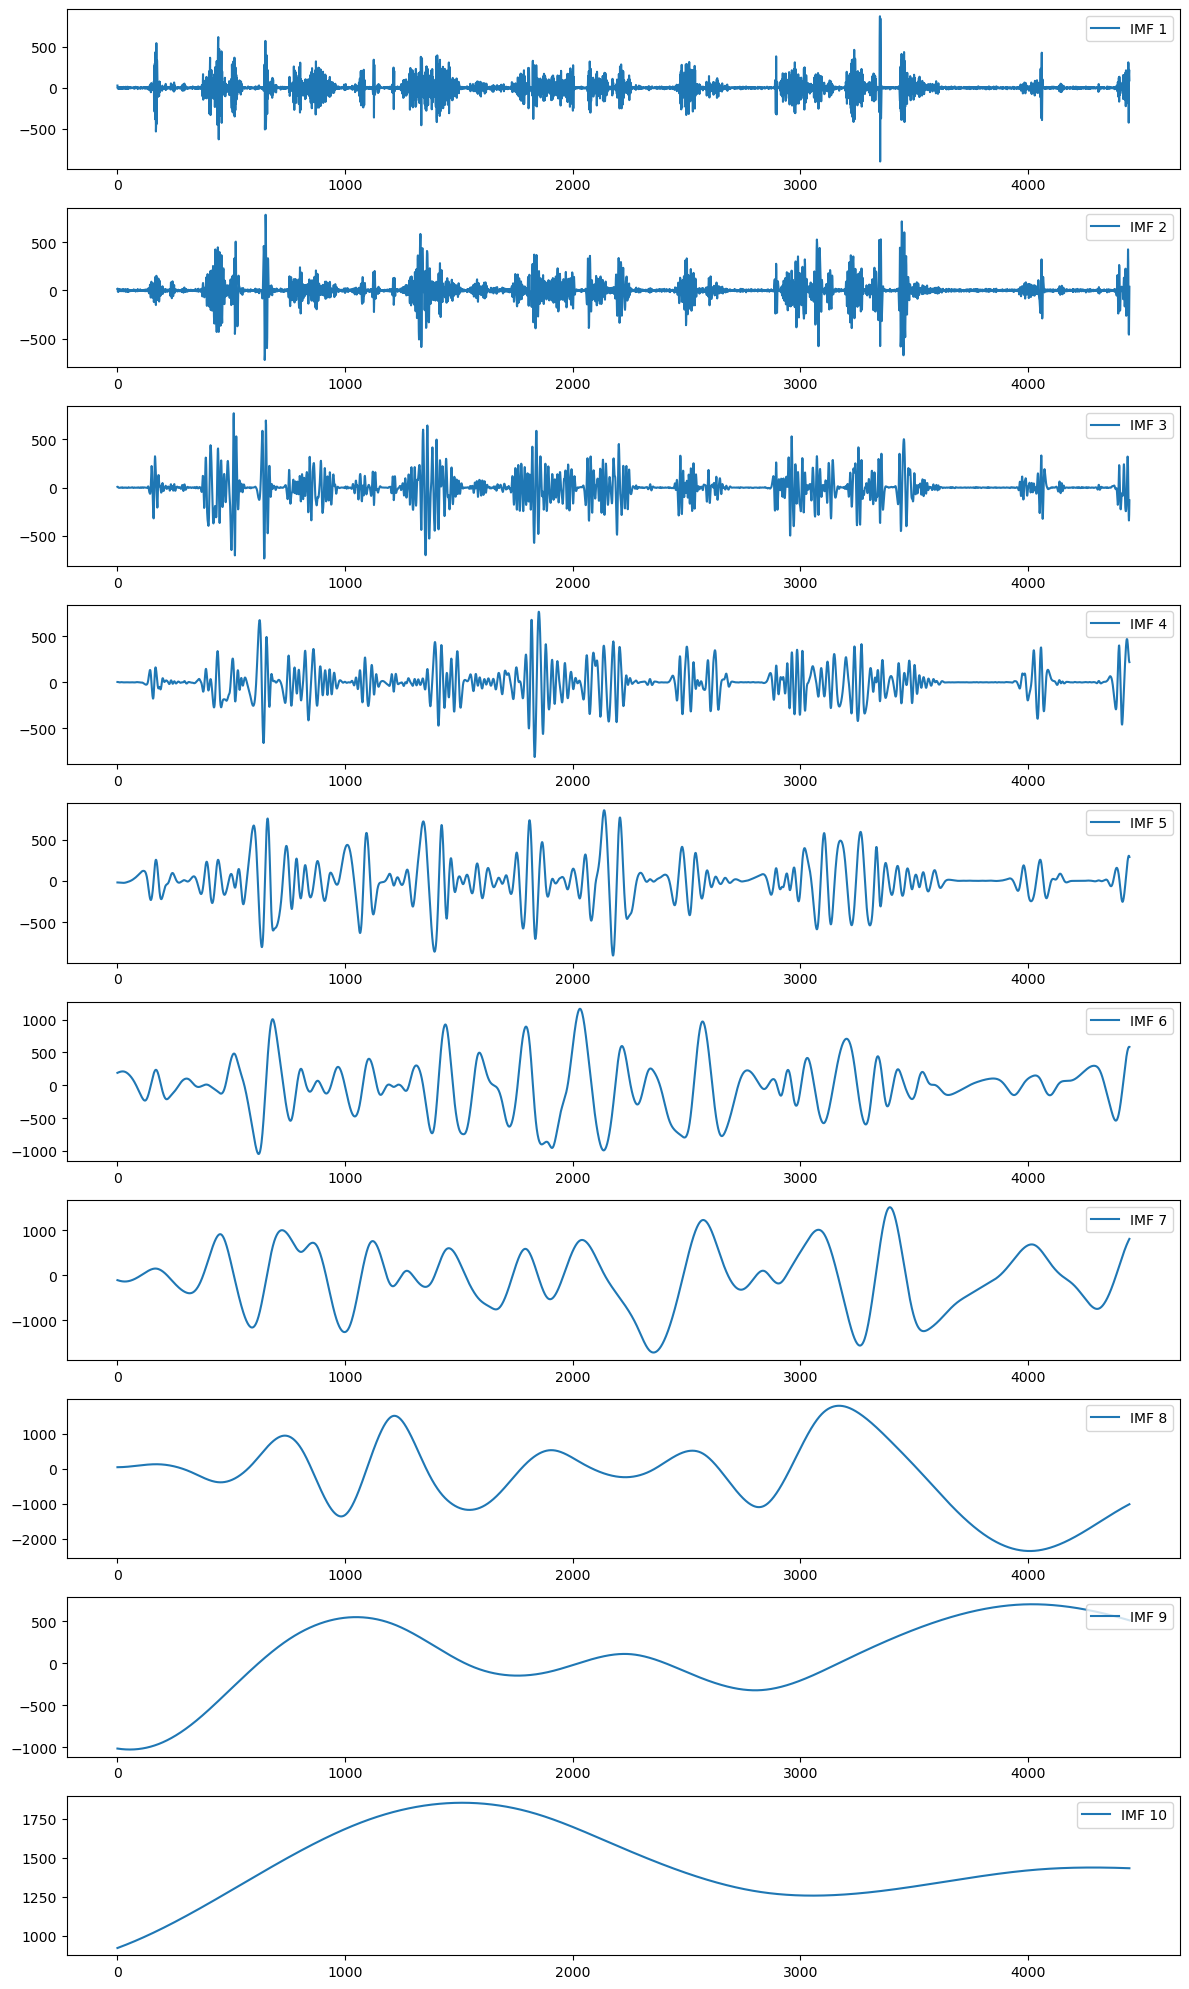

In [216]:
# Plot the CEEMDAN IMFs and the denoised signal
num_imfs = IMFs.shape[0]
plt.figure(figsize=(12, 2 * num_imfs))
for idx in range(num_imfs):
    plt.subplot(num_imfs, 1, idx + 1)
    plt.plot(ceemdan1.iloc[:, idx], label=f'IMF {idx + 1}')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

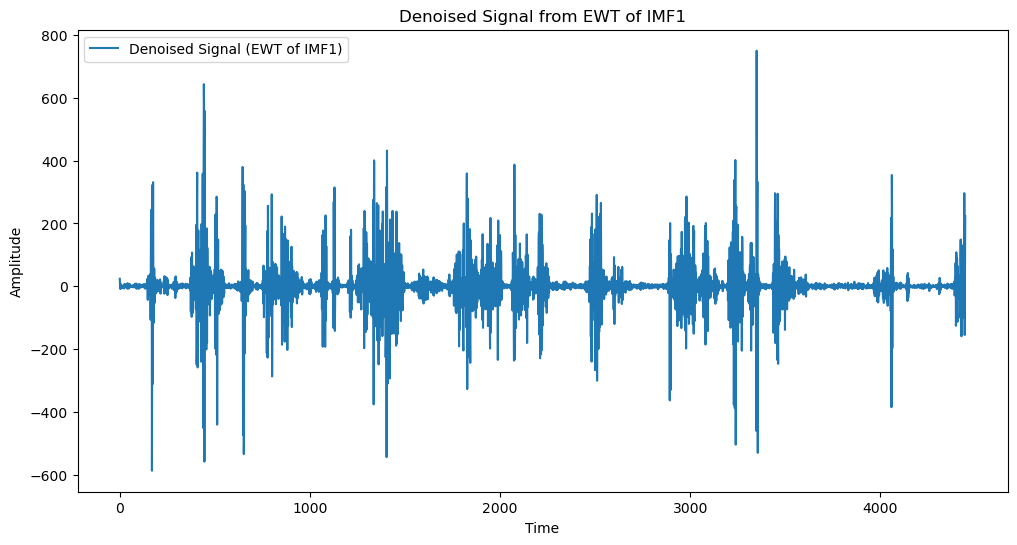

In [217]:
# Plot the denoised signal
plt.figure(figsize=(12, 6))
plt.plot(denoised, label='Denoised Signal (EWT of IMF1)')
plt.title('Denoised Signal from EWT of IMF1')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


In [218]:
def create_xy(data, input_length, output_length):
    """
    Generates input (x) and output (y) pairs from time series data based on the specified input and output lengths.

    Parameters:
    - data (np.ndarray or list): The time series data as a numpy array or list.
    - input_length (int): The number of time steps for the input sequence.
    - output_length (int): The number of time steps for the output sequence.

    Returns:
    - x (np.ndarray): The array of input sequences with shape (num_samples, input_length).
    - y (np.ndarray): The array of output sequences with shape (num_samples, output_length).
    """
    x, y = [], []
    total_length = len(data)

    # Iterate over the dataset to create input-output pairs
    for i in range(total_length - input_length - output_length + 1):
        x.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    
    return np.array(x), np.array(y)

## Step 3: Buidling the EMD with LSTM

In [219]:
# Initialize lists to store predictions and actual values
pred_test = []
test_ori = []
pred_train = []
train_ori = []

# Set model parameters
epoch = 30
batch_size = 64
neuron = 128
lr = 0.001
optimizer_name = 'Adam'
input_length = 24
output_length = 6
data_partition = 0.8
cap = 100

In [220]:
for col in new_ceemdan.columns:
    # Prepare dataset for the current component
    dataset_col = new_ceemdan[col].values.reshape(-1, 1)
    train_size = int(len(dataset_col) * data_partition)
    train, test = dataset_col[:train_size], dataset_col[train_size:]
    
    # Create datasets for training and testing
    X_train, y_train = create_xy(train, input_length, output_length)
    X_test, y_test = create_xy(test, input_length, output_length)
    
    if len(X_train) == 0 or len(X_test) == 0:
        continue  # Skip if there is not enough data for this component

    # reshape the X_train and X_test by removing the last dimension
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])

    # reshape the y_train and y_test by removing the last dimensions
    y_train = y_train.reshape(y_train.shape[0], y_train.shape[1])
    y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])
    
    # Scale the data
    sc_X = StandardScaler()
    sc_y = StandardScaler()
    X_train = sc_X.fit_transform(X_train)
    y_train = sc_y.fit_transform(y_train)
    X_test = sc_X.transform(X_test)
    y_test = sc_y.transform(y_test)
    
    # Reshape input data for LSTM
    trainX_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    testX_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    # Set random seed for reproducibility
    np.random.seed(1234)
    tf.random.set_seed(1234)
    
    # Suppress TensorFlow warnings
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
    
    # Build and compile the LSTM model
    model = Sequential()
    model.add(Bidirectional(LSTM(units=neuron, input_shape=(trainX_reshaped.shape[1], trainX_reshaped.shape[2]))))
    model.add(Dense(6))
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss='mse', optimizer=optimizer)
    
    # Train the model
    model.fit(trainX_reshaped, y_train, epochs=epoch, batch_size=batch_size, verbose=0)
    
    # Make predictions
    y_pred_train = model.predict(trainX_reshaped)
    y_pred_test = model.predict(testX_reshaped)
    
    # Inverse transform predictions and actual values
    y_pred_train_inv = sc_y.inverse_transform(y_pred_train)
    y_pred_test_inv = sc_y.inverse_transform(y_pred_test)
    y_train_inv = sc_y.inverse_transform(y_train)
    y_test_inv = sc_y.inverse_transform(y_test)
    
    # Store predictions and actual values
    pred_train.append(y_pred_train_inv.flatten())
    pred_test.append(y_pred_test_inv.flatten())
    train_ori.append(y_train_inv.flatten())
    test_ori.append(y_test_inv.flatten())


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [221]:
# Convert lists to DataFrames
result_pred_test = pd.DataFrame(pred_test).T  # Transpose to align with actual values
result_pred_train = pd.DataFrame(pred_train).T

# Sum predictions across components
a = result_pred_test.sum(axis=1)
b = result_pred_train.sum(axis=1)


In [222]:
# shape of the data
a.shape , b.shape

((5166,), (21168,))

In [223]:
# Prepare actual data
dataset = dfs.values.reshape(-1, 1)
train_size = int(len(dataset) * data_partition)
train, test = dataset[:train_size], dataset[train_size:]

# Create datasets for training and testing
_, trainY = create_xy(train, input_length, output_length)
_, testY = create_xy(test, input_length, output_length)

# Reshape trainY and testY to 2D
trainY = trainY.reshape(trainY.shape[0], -1)
testY = testY.reshape(testY.shape[0], -1)

# Scale the data
sc_y_total = StandardScaler()
y_train_scaled = sc_y_total.fit_transform(trainY)
y_test_scaled = sc_y_total.transform(testY)

# Inverse transform actual values
y_test_inv = sc_y_total.inverse_transform(y_test_scaled).flatten()
y_train_inv = sc_y_total.inverse_transform(y_train_scaled).flatten()


In [224]:
# Ensure the lengths match
min_length = min(len(a), len(y_test_inv))
a = a[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, a))
mae = mean_absolute_error(y_test_series, a)
r2 = r2_score(y_test_series, a)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")


RMSE: 132.021
MAE: 105.764
R2: 0.910


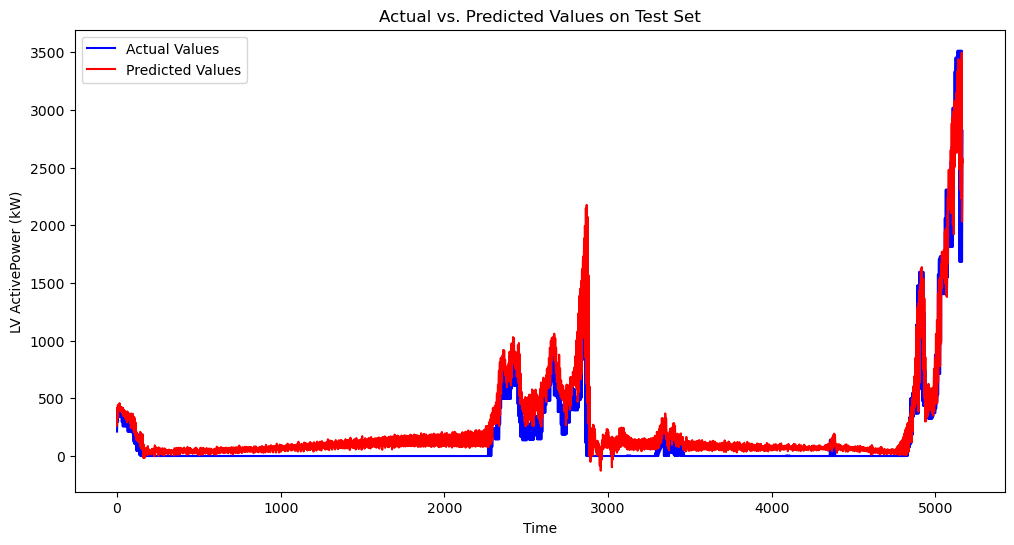

In [225]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_series, label='Actual Values', color='blue')
plt.plot(a.values, label='Predicted Values', color='red')
plt.title('Actual vs. Predicted Values on Test Set')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()
